# **Financial Risk Analysis with Python - JP Morgan**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\jp_morgan.csv")
print(df)

     TransactionID CustomerID AccountID AccountType TransactionType  \
0                3   CUST2412  ACC80131        Loan      Withdrawal   
1               32   CUST1467  ACC74631     Current      Withdrawal   
2                9   CUST2699  ACC39482        Loan      Withdrawal   
3               42   CUST9535  ACC82947     Current      Withdrawal   
4              166   CUST7459  ACC39500      Credit         Payment   
..             ...        ...       ...         ...             ...   
795            157   CUST4346  ACC48303     Savings         Payment   
796             46   CUST7120  ACC42710     Current        Transfer   
797             79   CUST5574  ACC89098     Current      Withdrawal   
798            189   CUST9754  ACC86784        Loan         Deposit   
799            175   CUST3725  ACC34119        Loan      Withdrawal   

             Product    Firm Region    Manager TransactionDate  \
0      Personal Loan  Firm C   West  Manager 3      06-08-2023   
1          Home

### Task 1: Data Cleaning and Formatting

In [6]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='str')


In [7]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97355,113405.32820,0.380675,411,13


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    str    
 2   AccountID          800 non-null    str    
 3   AccountType        800 non-null    str    
 4   TransactionType    800 non-null    str    
 5   Product            800 non-null    str    
 6   Firm               800 non-null    str    
 7   Region             800 non-null    str    
 8   Manager            800 non-null    str    
 9   TransactionDate    800 non-null    str    
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), str(9)
memory usage: 93.9 KB


In [14]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y', errors='coerce')

In [15]:
print(df['TransactionDate'].dtype)

datetime64[us]


In [9]:
df['AccountType'] = df['AccountType'].str.strip().str.title()

### Task 2: Descriptive Transactional Analysis

##### Task 2.1 Calculate monthly and yearly summaries of total credits, debits and net transaction volume.

In [ ]:
#Creating credit column
df["Credit"] = df["TransactionAmount"].where(df["TransactionType"] == "deposit", 0)

#Creating Debit Column
df["Debit"] = df["TransactionAmount"].where(df["TransactionType"].isin(["Withdrawal","Transfer","Payment"]), 0)

#Net Transaction
df["Net_Transaction"] = df["Credit"] - df["Debit"]

In [8]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Debit,Credit,Net_Transaction
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69057,126486.40830,0.225824,611,89,33759.69057,0.0,-33759.69057
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.19933,24834.76291,0.335717,817,174,69319.19933,0.0,-69319.19933
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48483,123007.43530,0.572453,332,31,42831.48483,0.0,-42831.48483
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.79697,73073.64225,0.571993,626,92,70903.79697,0.0,-70903.79697
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97355,113405.32820,0.380675,411,13,21948.97355,0.0,-21948.97355



##### Task 2.2 Plot trends in total credits vs. debits over time


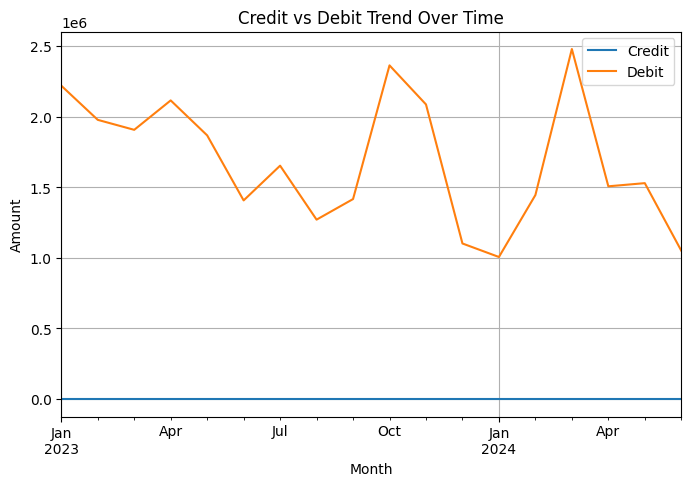

In [10]:
# Monthly trend graph
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y', errors='coerce')
df["Month"] = df["TransactionDate"].dt.to_period("M")

monthly = df.groupby("Month")[["Credit","Debit"]].sum()
monthly.plot(figsize=(8,5))
plt.title("Credit vs Debit Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.show()


##### Task 2.3 Identify top and bottom performing accounts based on net inflow.

In [11]:
#Top 5 accounts
account_flow = df.groupby("AccountID")["Net_Transaction"].sum()
top5 = account_flow.nlargest(5)
top5_df = top5.reset_index()
top5_df

,AccountID,Net_Transaction
0,ACC28305,739.392565
1,ACC11837,0.000000
2,ACC28292,0.000000
3,ACC46953,0.000000
4,ACC52650,0.000000


In [12]:
#Bottom 5 accounts
bottom5 = account_flow.nsmallest(5)
bottom5_df = bottom5.reset_index()
bottom5_df

,AccountID,Net_Transaction
0,ACC18140,-458219.210460
1,ACC55331,-448188.410346
2,ACC51593,-414370.119240
3,ACC81631,-413192.967930
4,ACC82298,-382768.181610


##### Task 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions

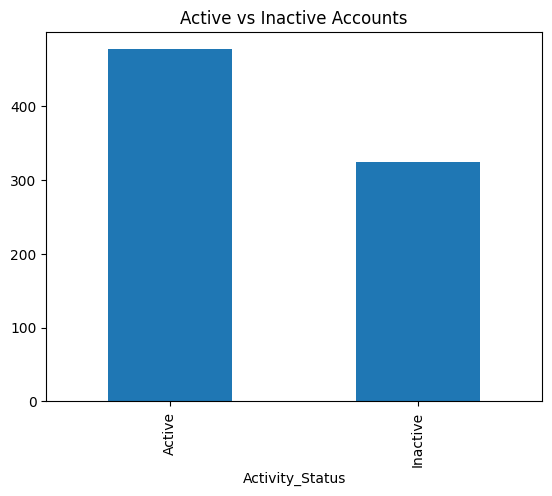

In [13]:
df = df.sort_values(by=["AccountID", "TransactionDate"])
df["Days_Gap"] = df.groupby("AccountID")["TransactionDate"].diff().dt.days
df["Activity_Status"] = df["Days_Gap"].apply(lambda x: "Inactive" if x >= 60 else "Active")
df["Activity_Status"].value_counts().plot(kind="bar")
plt.title("Active vs Inactive Accounts")
plt.show()

##### Task 3 Customer Profile Building
Task 3.1 Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [14]:
account_activity = df.groupby('AccountID').size().reset_index(name='TransactionCount')

In [15]:
def classify_activity(count):
    if count > 50:
        return 'High'
    elif count >= 20:
        return 'Medium'
    else:
        return 'Low'

account_activity['ActivityLevel'] = account_activity['TransactionCount'].apply(classify_activity)

In [16]:
df = df.merge(account_activity[['AccountID', 'ActivityLevel']], on='AccountID', how='left')

In [17]:
activity_summary = account_activity['ActivityLevel'].value_counts()
activity_summary

ActivityLevel
Low    194
Name: count, dtype: int64

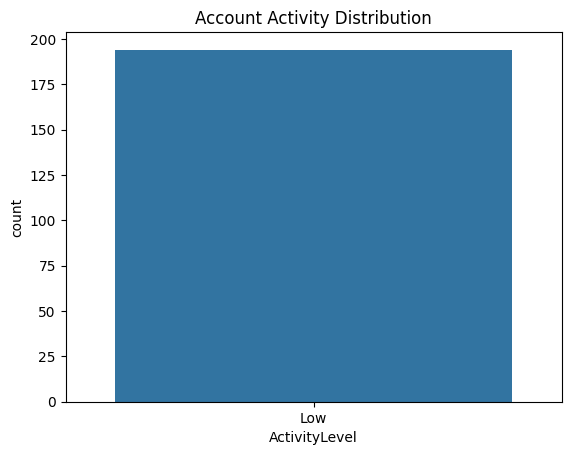

In [18]:
sns.countplot(x='ActivityLevel', data=account_activity)
plt.title("Account Activity Distribution")
plt.show()

##### Task 3.2 Segment customers by average balance and transaction volume.

In [19]:
customer_df = df.groupby('CustomerID').agg({
    'AccountBalance': 'mean',
    'TransactionAmount': 'sum'
}).reset_index()

customer_df.rename(columns={
    'AccountBalance': 'AvgBalance',
    'TransactionAmount': 'TotalTransaction'
}, inplace=True)

In [20]:
# Balance thresholds
bal_low = customer_df['AvgBalance'].quantile(0.33)
bal_high = customer_df['AvgBalance'].quantile(0.66)

# Transaction thresholds
txn_low = customer_df['TotalTransaction'].quantile(0.33)
txn_high = customer_df['TotalTransaction'].quantile(0.66)

In [21]:
def balance_segment(x):
    if x < bal_low:
        return 'Low Balance'
    elif x <= bal_high:
        return 'Medium Balance'
    else:
        return 'High Balance'

def transaction_segment(x):
    if x < txn_low:
        return 'Low Volume'
    elif x <= txn_high:
        return 'Medium Volume'
    else:
        return 'High Volume'

In [22]:
customer_df['BalanceSegment'] = customer_df['AvgBalance'].apply(balance_segment)
customer_df['TransactionSegment'] = customer_df['TotalTransaction'].apply(transaction_segment)
customer_df['CustomerSegment'] = customer_df['BalanceSegment'] + ' | ' + customer_df['TransactionSegment']
customer_df['CustomerSegment'].value_counts()

CustomerSegment
Low Balance | Low Volume          27
Medium Balance | High Volume      25
High Balance | High Volume        24
Medium Balance | Medium Volume    22
High Balance | Low Volume         21
Low Balance | Medium Volume       20
High Balance | Medium Volume      20
Low Balance | High Volume         16
Medium Balance | Low Volume       15
Name: count, dtype: int64

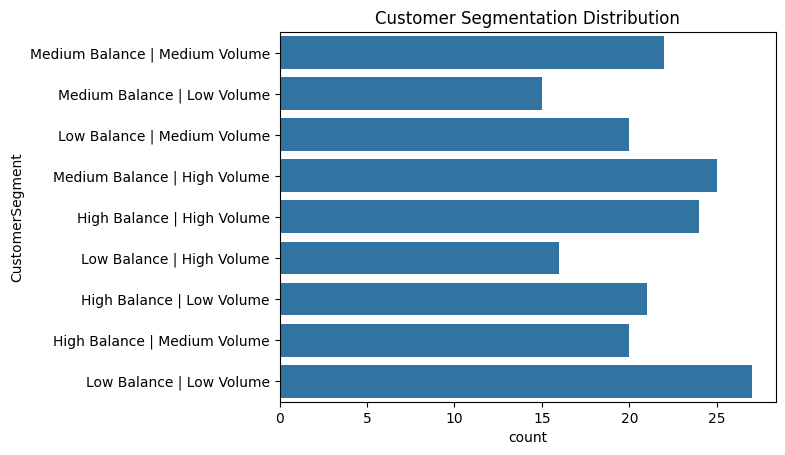

In [23]:
sns.countplot(y='CustomerSegment', data=customer_df)
plt.title("Customer Segmentation Distribution")
plt.show()

##### Task 3.3 Create profiles for:
○ High-net inflow accounts
○ High-frequency low-balance accounts
○ Accounts with negative or near-zero balances

In [24]:
customer_profile = df.groupby('CustomerID').agg({
    'TransactionAmount': 'sum',
    'AccountBalance': 'mean',
    'TransactionID': 'count'
}).reset_index()

customer_profile.rename(columns={
    'TransactionAmount': 'TotalTransaction',
    'AccountBalance': 'AvgBalance',
    'TransactionID': 'TransactionCount'
}, inplace=True)

In [25]:
credit_types = ['Deposit', 'Transfer']
debit_types = ['Withdrawal', 'Payment']

df['Credit'] = df['TransactionAmount'].where(df['TransactionType'].isin(credit_types), 0)
df['Debit'] = df['TransactionAmount'].where(df['TransactionType'].isin(debit_types), 0)

net_flow = df.groupby('CustomerID').agg({
    'Credit': 'sum',
    'Debit': 'sum'
}).reset_index()

net_flow['NetFlow'] = net_flow['Credit'] - net_flow['Debit']

In [26]:
customer_profile = customer_profile.merge(net_flow[['CustomerID', 'NetFlow']], on='CustomerID')

In [27]:
# Net inflow threshold
net_threshold = customer_profile['NetFlow'].quantile(0.70)

# High frequency threshold
freq_threshold = customer_profile['TransactionCount'].quantile(0.70)

# Low balance threshold
low_balance_threshold = customer_profile['AvgBalance'].quantile(0.30)

# Near-zero threshold
near_zero_threshold = customer_profile['AvgBalance'].quantile(0.10)

In [28]:
def assign_profile(row):
    if row['NetFlow'] > net_threshold:
        return 'High-Net Inflow'
    
    elif row['TransactionCount'] > freq_threshold and row['AvgBalance'] < low_balance_threshold:
        return 'High-Freq Low-Balance'
    
    elif row['AvgBalance'] <= near_zero_threshold:
        return 'Near-Zero Balance'
    
    else:
        return 'Regular'

customer_profile['Profile'] = customer_profile.apply(assign_profile, axis=1)

In [29]:
customer_profile['Profile'].value_counts()

Profile
Regular                  117
High-Net Inflow           57
Near-Zero Balance         14
High-Freq Low-Balance      2
Name: count, dtype: int64

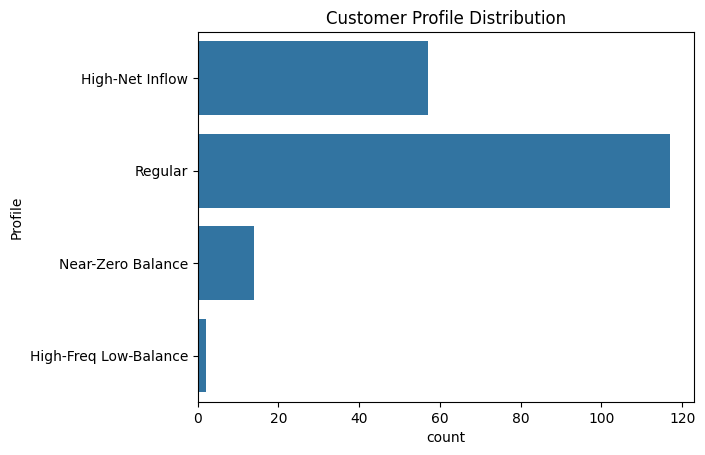

In [30]:
sns.countplot(y='Profile', data=customer_profile)
plt.title("Customer Profile Distribution")
plt.show()

### Task 4 Financial Risk Identification

##### Task 4.1 Track accounts with frequent large withdrawals or overdrafts.

In [49]:
# Large withdrawal threshold (top 20%)
large_withdrawal_threshold = df[df['TransactionType'] == 'Withdrawal']['TransactionAmount'].quantile(0.80)

# Near-zero/overdraft threshold (bottom 10%)
low_balance_threshold = df['AccountBalance'].quantile(0.10)

In [50]:
large_withdrawals = df[
    (df['TransactionType'] == 'Withdrawal') &
    (df['TransactionAmount'] > large_withdrawal_threshold)
]

In [52]:
withdrawal_freq = large_withdrawals.groupby('AccountID').size().reset_index(name='LargeWithdrawalCount')
frequent_large_accounts = withdrawal_freq[withdrawal_freq['LargeWithdrawalCount'] >= 3]

In [53]:
overdraft_accounts = df[
    (df['AccountBalance'] < 0) |
    (df['AccountBalance'] <= low_balance_threshold)
][['AccountID']].drop_duplicates()

In [54]:
frequent_large_accounts['RiskType'] = 'Frequent Large Withdrawals'
overdraft_accounts['RiskType'] = 'Overdraft / Low Balance'

# Combine
risk_accounts = pd.concat([
    frequent_large_accounts[['AccountID', 'RiskType']],
    overdraft_accounts[['AccountID', 'RiskType']]
]).drop_duplicates()

risk_accounts

,AccountID,RiskType
8,ACC11062,Overdraft / Low Balance
30,ACC13357,Overdraft / Low Balance
34,ACC15228,Overdraft / Low Balance
41,ACC15671,Overdraft / Low Balance
65,ACC18140,Overdraft / Low Balance
...,...,...
710,ACC88449,Overdraft / Low Balance
723,ACC90887,Overdraft / Low Balance
774,ACC96868,Overdraft / Low Balance
781,ACC97411,Overdraft / Low Balance


In [55]:
risk_accounts['RiskType'].value_counts()

RiskType
Overdraft / Low Balance    62
Name: count, dtype: int64

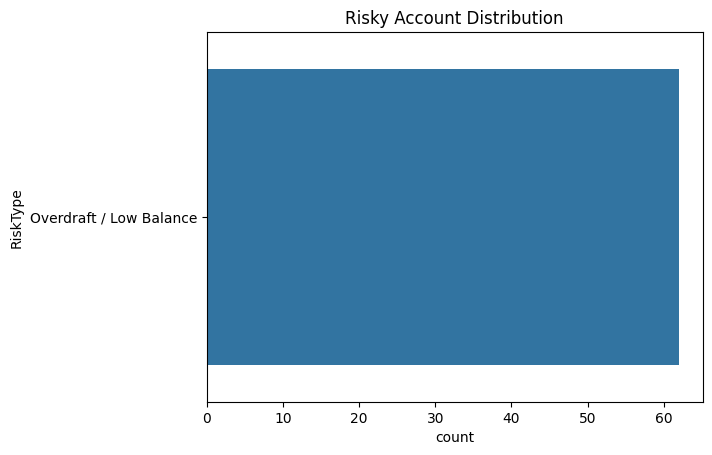

In [56]:
sns.countplot(y='RiskType', data=risk_accounts)
plt.title("Risky Account Distribution")
plt.show()

##### Task 4.2 Calculate balance volatility using standard deviation or coefficient of variation.

In [58]:
volatility_df = df.groupby('AccountID').agg({
    'AccountBalance': ['mean', 'std']
}).reset_index()
volatility_df.columns = ['AccountID', 'MeanBalance', 'StdDev']
volatility_df['CV'] = volatility_df['StdDev'] / volatility_df['MeanBalance']

In [59]:
def volatility_label(cv):
    if cv > 1:
        return 'High'
    elif cv >= 0.5:
        return 'Medium'
    else:
        return 'Low'

volatility_df['VolatilityLevel'] = volatility_df['CV'].apply(volatility_label)

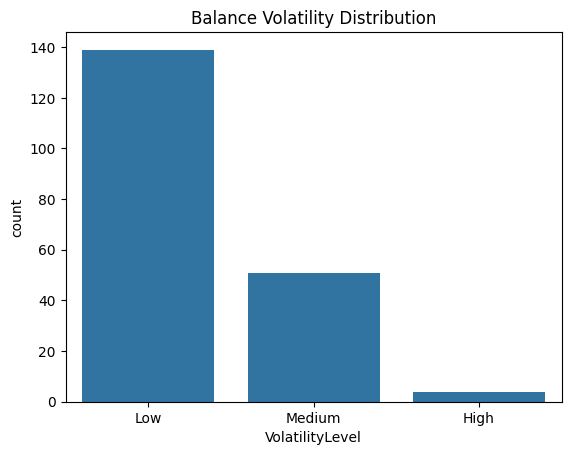

In [60]:
sns.countplot(x='VolatilityLevel', data=volatility_df)
plt.title("Balance Volatility Distribution")
plt.show()

##### Task 4.3 Use IQR or z-score methods to detect anomalies.

In [ ]:
#Using IQR
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_anomalies = df[
    (df['TransactionAmount'] < lower_bound) |
    (df['TransactionAmount'] > upper_bound)
]
iqr_anomalies.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Month,Year,Credit,Debit,Net_Transaction,Days_Gap,Activity_Status,ActivityLevel
160,67,CUST6391,ACC26940,Current,Payment,Home Loan,Firm A,South,Manager 4,2023-03-16,...,315,209,2023-03,2023,0.00000,-25964.94612,0.0,10.0,Active,Low
319,161,CUST4373,ACC41829,Current,Payment,Savings Account,Firm A,North,Manager 3,2024-03-22,...,469,175,2024-03,2024,0.00000,135972.34390,0.0,NaN,Active,Low
370,191,CUST6837,ACC46655,Current,Deposit,Mutual Fund,Firm E,West,Manager 2,2024-06-16,...,466,150,2024-06,2024,-29563.97803,0.00000,0.0,131.0,Inactive,Low
400,178,CUST1189,ACC50439,Savings,Deposit,Savings Account,Firm D,East,Manager 1,2024-06-16,...,655,17,2024-06,2024,-60979.07348,0.00000,0.0,103.0,Inactive,Low
612,21,CUST1644,ACC77533,Credit,Payment,Personal Loan,Firm D,South,Manager 4,2023-12-24,...,678,42,2023-12,2023,0.00000,-30826.73980,0.0,59.0,Active,Low


##### Task 4.4 Highlight customers with irregular or suspicious transaction behavior.

In [62]:
customer = df.groupby('CustomerID').agg({
    'TransactionAmount': ['sum', 'mean', 'std'],
    'AccountBalance': 'mean',
    'TransactionID': 'count'
}).reset_index()

customer.columns = ['CustomerID', 'TotalTxn', 'AvgTxn', 'StdTxn', 'AvgBalance', 'TxnCount']

In [63]:
customer['CV'] = customer['StdTxn'] / customer['AvgTxn']
customer['CV'] = customer['CV'].replace([float('inf'), -float('inf')], 0)

In [64]:
# Large withdrawal threshold
large_withdrawal_threshold = df[df['TransactionType'] == 'Withdrawal']['TransactionAmount'].quantile(0.80)

# Low balance threshold
low_balance_threshold = customer['AvgBalance'].quantile(0.10)

In [65]:
large_withdrawals = df[
    (df['TransactionType'] == 'Withdrawal') &
    (df['TransactionAmount'] > large_withdrawal_threshold)
]

withdrawal_count = large_withdrawals.groupby('CustomerID').size().reset_index(name='LargeWithdrawalCount')

customer = customer.merge(withdrawal_count, on='CustomerID', how='left')
customer['LargeWithdrawalCount'] = customer['LargeWithdrawalCount'].fillna(0)

In [66]:
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Anomaly'] = ((df['TransactionAmount'] < lower) | (df['TransactionAmount'] > upper)).astype(int)

anomaly_count = df.groupby('CustomerID')['Anomaly'].sum().reset_index()
customer = customer.merge(anomaly_count, on='CustomerID', how='left')

In [67]:
def flag_suspicious(row):
    if (
        row['CV'] > 1 or
        row['LargeWithdrawalCount'] >= 3 or
        row['AvgBalance'] <= low_balance_threshold or
        row['Anomaly'] > 0
    ):
        return 'Suspicious'
    else:
        return 'Normal'

customer['RiskFlag'] = customer.apply(flag_suspicious, axis=1)

In [68]:
customer['RiskFlag'].value_counts()

RiskFlag
Normal        149
Suspicious     41
Name: count, dtype: int64

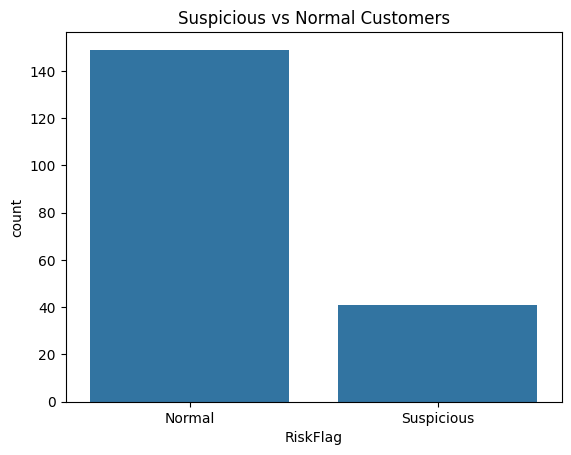

In [69]:
sns.countplot(x='RiskFlag', data=customer)
plt.title("Suspicious vs Normal Customers")
plt.show()

### Task 5 Visualisation
##### Conduct extensive exploratory data analysis with attractive visualizations for your findings

In [70]:
df.info()
df.describe()
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    str           
 2   AccountID          800 non-null    str           
 3   AccountType        800 non-null    str           
 4   TransactionType    800 non-null    str           
 5   Product            800 non-null    str           
 6   Firm               800 non-null    str           
 7   Region             800 non-null    str           
 8   Manager            800 non-null    str           
 9   TransactionDate    800 non-null    datetime64[us]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMonths       80

TransactionID        197
CustomerID           190
AccountID            194
AccountType            4
TransactionType        4
Product                5
Firm                   5
Region                 5
Manager                4
TransactionDate      166
TransactionAmount    800
AccountBalance       800
RiskScore            800
CreditRating         423
TenureMonths         228
Month                 18
Year                   2
Credit               378
Debit                424
Net_Transaction        1
Days_Gap             228
Activity_Status        2
ActivityLevel          1
Anomaly                2
dtype: int64

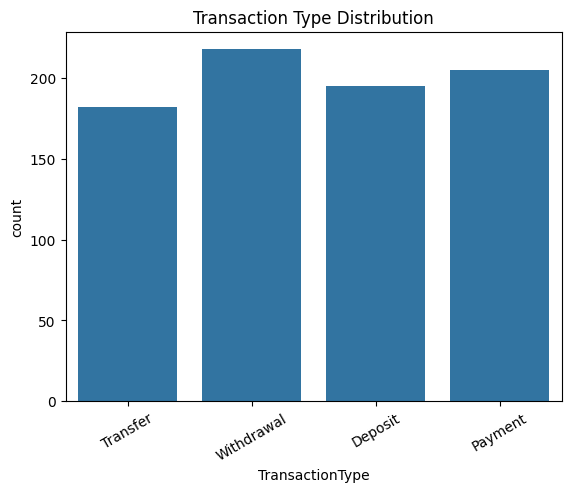

In [71]:
sns.countplot(x='TransactionType', data=df)
plt.title("Transaction Type Distribution")
plt.xticks(rotation=30)
plt.show()

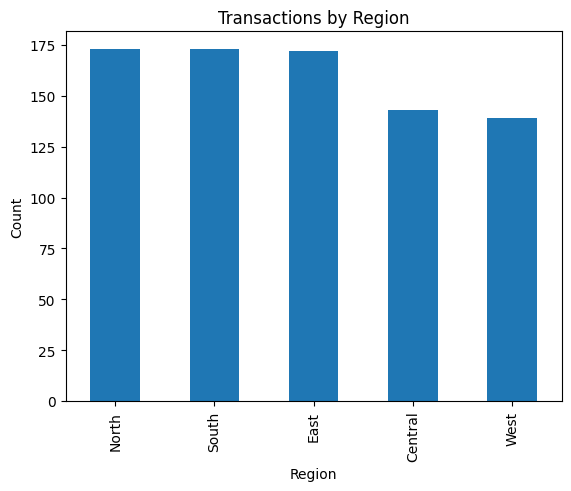

In [72]:
region_counts = df['Region'].value_counts()

region_counts.plot(kind='bar')
plt.title("Transactions by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

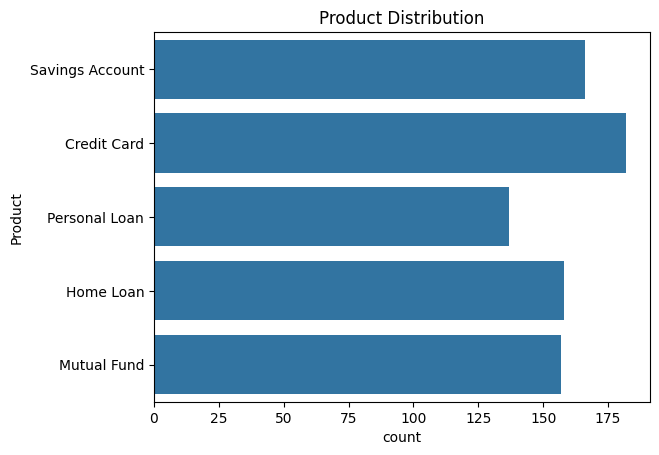

In [73]:
sns.countplot(y='Product', data=df)
plt.title("Product Distribution")
plt.show()

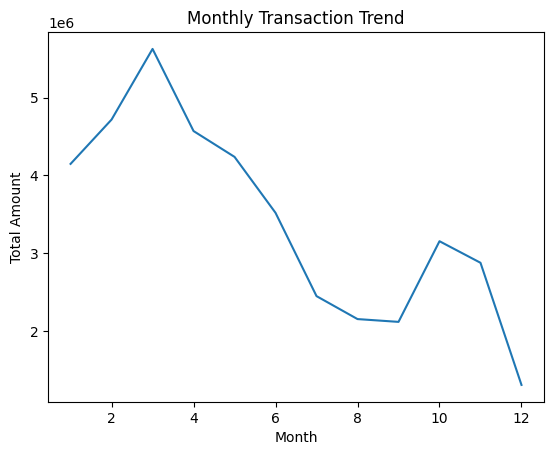

In [74]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y')

monthly = df.groupby(df['TransactionDate'].dt.month)['TransactionAmount'].sum()

monthly.plot()
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.show()

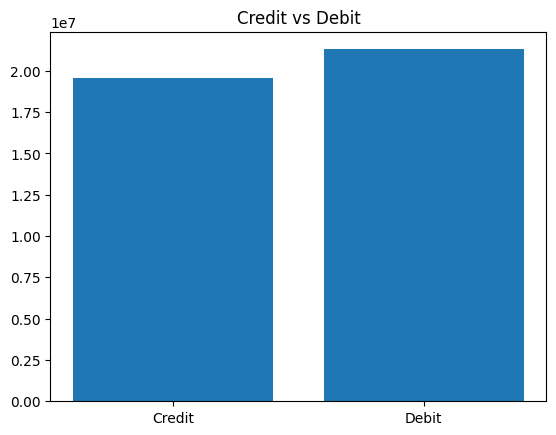

In [75]:
credit = df[df['TransactionType'].isin(['Deposit','Transfer'])]['TransactionAmount'].sum()
debit = df[df['TransactionType'].isin(['Withdrawal','Payment'])]['TransactionAmount'].sum()

plt.bar(['Credit','Debit'], [credit, debit])
plt.title("Credit vs Debit")
plt.show()

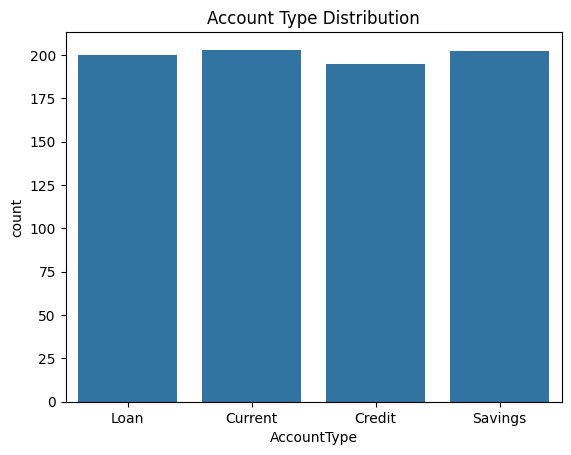

In [76]:
sns.countplot(x='AccountType', data=df)
plt.title("Account Type Distribution")
plt.show()

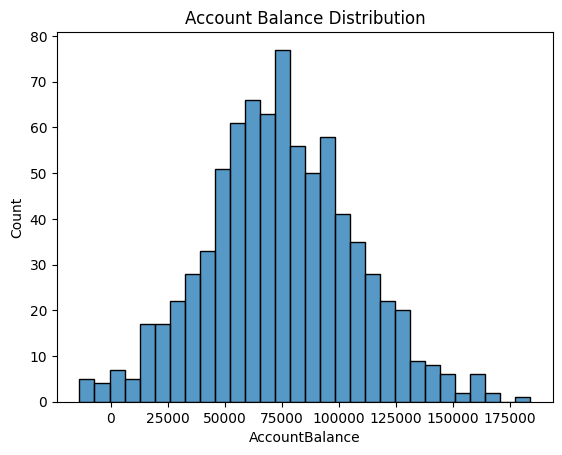

In [77]:
sns.histplot(df['AccountBalance'], bins=30)
plt.title("Account Balance Distribution")
plt.show()

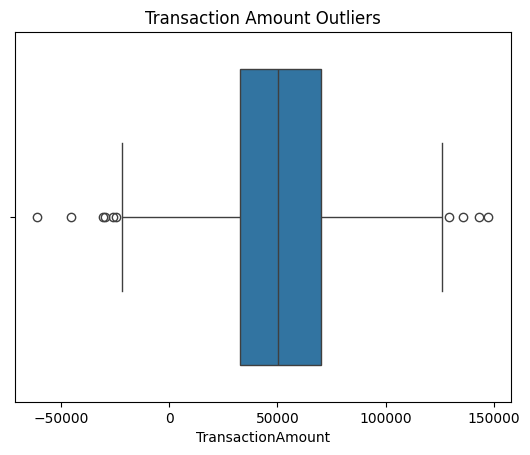

In [78]:
sns.boxplot(x=df['TransactionAmount'])
plt.title("Transaction Amount Outliers")
plt.show()

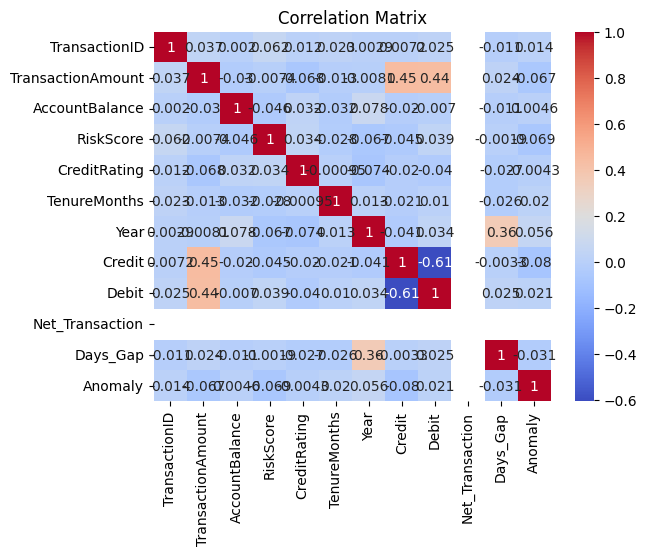

In [79]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [80]:
sns.set(style='whitegrid')
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

### Task 6 Hypothesis Testing
##### Task 6.1 Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

In [81]:
customer = df.groupby('AccountID').agg({
    'TransactionAmount': 'sum',
    'AccountBalance': 'mean'
}).reset_index()

customer.columns = ['AccountID', 'TotalTxn', 'AvgBalance']

In [82]:
high_threshold = customer['TotalTxn'].quantile(0.70)
low_threshold = customer['TotalTxn'].quantile(0.30)

high_volume = customer[customer['TotalTxn'] >= high_threshold]['AvgBalance']
low_volume = customer[customer['TotalTxn'] <= low_threshold]['AvgBalance']

In [84]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_volume, low_volume, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.40151426749154395
P-value: 0.6889782326868009


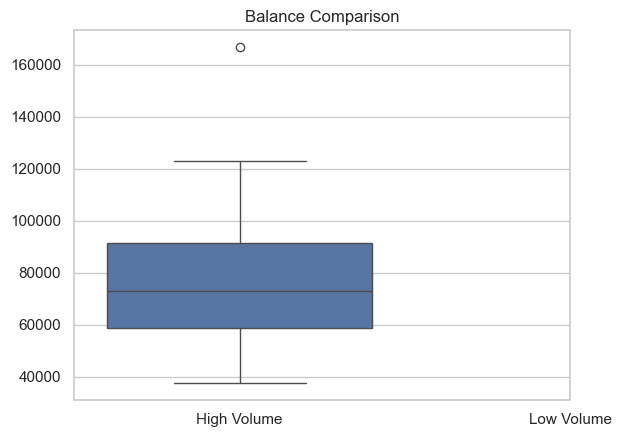

In [85]:
sns.boxplot(data=[high_volume, low_volume])
plt.xticks([0,1], ['High Volume', 'Low Volume'])
plt.title("Balance Comparison")
plt.show()

##### Task 6.2 Conduct hypothesis testing based on segmentation.

In [86]:
customer = df.groupby('CustomerID').agg({
    'AccountBalance': 'mean',
    'TransactionAmount': 'sum'
}).reset_index()

customer.columns = ['CustomerID', 'AvgBalance', 'TotalTxn']

In [87]:
low = customer['AvgBalance'].quantile(0.33)
high = customer['AvgBalance'].quantile(0.66)

def segment_balance(x):
    if x < low:
        return 'Low'
    elif x <= high:
        return 'Medium'
    else:
        return 'High'

customer['BalanceSegment'] = customer['AvgBalance'].apply(segment_balance)

In [88]:
high_group = customer[customer['BalanceSegment'] == 'High']['TotalTxn']
low_group = customer[customer['BalanceSegment'] == 'Low']['TotalTxn']

In [89]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_group, low_group, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 1.1349456265732278
P-value: 0.2585726907884876


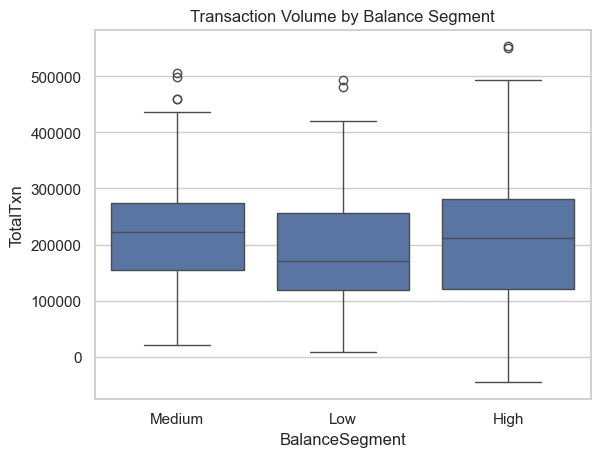

In [90]:
sns.boxplot(x='BalanceSegment', y='TotalTxn', data=customer)
plt.title("Transaction Volume by Balance Segment")
plt.show()